# **Streaming Malware Classification with Drift Detection**

# **Introduction**<br>This notebook implements a streaming classification pipeline for malware data, using SGDClassifier (for efficient online updates) and RandomForestClassifier (retrained upon concept drift detection). KSWIN is employed as the concept drift detector.

## **1. Setup and Library Imports**

In [1]:
import os
import math
import joblib
import zipfile
import subprocess
import sys
import glob
import shutil
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc, f1_score, precision_score, recall_score
)

## **2. KSWIN Drift Detector Implementation**

# **The code attempts to use scikit-multiflow, falling back to River if unavailable.**

In [2]:
try:
    from skmultiflow.drift_detection import KSWIN as SKKSWIN
    class DriftAdapter:
        def __init__(self, *args, **kwargs):
            self.detector = SKKSWIN(*args, **kwargs)
        def add_element(self, x):
            return self.detector.add_element(x)
        def detected_change(self):
            return self.detector.detected_change()
        def reset(self):
            return self.detector.reset()
        @property
        def window_size(self):
            return getattr(self.detector, "window_size", None)
    drift = DriftAdapter()
    print("Using scikit-multiflow's KSWIN drift detector.")
except Exception:
    print("scikit-multiflow not available. Falling back to River's KSWIN. Installing River if needed...")
    try:
        from river import drift as river_drift
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "river"])
        from river import drift as river_drift
    class DriftAdapter:
        def __init__(self, *args, **kwargs):
            self.detector = river_drift.KSWIN(*args, **kwargs)
        def add_element(self, x):
            try:
                self.detector.update(x)
            except TypeError:
                _ = self.detector.update(x)
        def detected_change(self):
            return bool(getattr(self.detector, "drift_detected", False))
        def reset(self):
            try:
                self.detector.reset()
            except Exception:
                cls = type(self.detector)
                self.detector = cls()
        @property
        def window_size(self):
            return getattr(self.detector, "window_size", None)
    drift = DriftAdapter()
    print("Using River's KSWIN drift detector (wrapped).")

scikit-multiflow not available. Falling back to River's KSWIN. Installing River if needed...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.1 MB/s eta 0:00:00
Using River's KSWIN drift detector (wrapped).


## **3. Configuration and Output Setup**

In [3]:
initial_year = "2010-09-01"
CSV_FILE = "/kaggle/input/fast-furious-malware-data-stream/drebin_drift.parquet.zip"
OUTPUT_DIR = "/kaggle/working/sgd_rf_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## **4. Dataset Management and Download**

# **The function `ensure_dataset_present` handles checking for the dataset location and automatically downloading it if required, using Kaggle CLI or gdown.**

In [4]:
def ensure_dataset_present():
    global CSV_FILE
    if os.path.exists(CSV_FILE):
        print("Dataset found at:", CSV_FILE)
        return
    print(f"Dataset not found at {CSV_FILE}. Attempting to download dataset to /content using Kaggle CLI...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle", "gdown"])
    except subprocess.CalledProcessError as e:
        print("Failed to pip-install kaggle/gdown:", e)
    gdrive_id = "1F8GF0sfxrGZDOc5ALy2-_JLPlw04HCq-"
    kaggle_json_local = "kaggle.json"
    try:
        if not os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
            subprocess.check_call(["gdown", "--id", gdrive_id, "-O", kaggle_json_local])
            kaggle_dir = os.path.expanduser("~/.kaggle")
            os.makedirs(kaggle_dir, exist_ok=True)
            dest = os.path.join(kaggle_dir, "kaggle.json")
            shutil.move(kaggle_json_local, dest)
            os.chmod(dest, 0o600)
            print("kaggle.json downloaded and moved to ~/.kaggle/kaggle.json")
        else:
            print("Found existing ~/.kaggle/kaggle.json; using it.")
    except Exception as e:
        print("Warning: could not place kaggle.json:", e)
    os.environ["KAGGLE_CONFIG_DIR"] = os.path.expanduser("~/.kaggle")
    def run_kaggle_cmd(cmd, retries=3, sleep_base=5):
        last_exc = None
        for attempt in range(1, retries + 1):
            try:
                print(f"Running kaggle command (attempt {attempt}/{retries}): {' '.join(cmd)}")
                subprocess.check_call(cmd)
                return True
            except Exception as e:
                print(f"Kaggle command attempt {attempt} failed: {e}")
                last_exc = e
                time.sleep(sleep_base * attempt)
        raise last_exc
    try:
        try:
            subprocess.check_call(["kaggle", "datasets", "files", "fabriciojoc/fast-furious-malware-data-stream"])
        except Exception:
            pass
        single_file_cmd = [
            "kaggle", "datasets", "download", "-d",
            "fabriciojoc/fast-furious-malware-data-stream",
            "-f", "drebin_drift.parquet.zip",
            "-p", "/content"
        ]
        run_kaggle_cmd(single_file_cmd, retries=3, sleep_base=5)
        candidate = "/content/drebin_drift.parquet.zip"
        if not os.path.exists(candidate):
            candidates = glob.glob("/content/**/drebin*.*", recursive=True) + glob.glob("/content/drebin*.*")
            if candidates:
                candidate = candidates[0]
        if os.path.exists(candidate):
            CSV_FILE = candidate
            print("Downloaded dataset file:", CSV_FILE)
            return
    except Exception as e:
        print("Download attempt failed:", e)
    message = "Could not automatically download the dataset. Please place the file and try again."
    print(message)
    raise FileNotFoundError(message)
ensure_dataset_present()
print("Reading dataset from:", CSV_FILE)

Dataset not found at /kaggle/input/fast-furious-malware-data-stream/drebin_drift.parquet.zip. Attempting to download dataset to /content using Kaggle CLI...


/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1F8GF0sfxrGZDOc5ALy2-_JLPlw04HCq-
To: /kaggle/working/kaggle.json
100%|██████████| 68.0/68.0 [00:00<00:00, 295kB/s]


kaggle.json downloaded and moved to ~/.kaggle/kaggle.json
name                            size  creationDate                
------------------------  ----------  --------------------------  
androbin.parquet.zip      8779316662  2022-08-12 04:17:30.764000  
drebin_drift.parquet.zip    16634133  2022-08-12 04:15:22.985000  
Running kaggle command (attempt 1/3): kaggle datasets download -d fabriciojoc/fast-furious-malware-data-stream -f drebin_drift.parquet.zip -p /content
Dataset URL: https://www.kaggle.com/datasets/fabriciojoc/fast-furious-malware-data-stream
License(s): other

Downloaded dataset file: /content/drebin_drift.parquet.zip
Reading dataset from: /content/drebin_drift.parquet.zip


100%|██████████| 15.9M/15.9M [00:00<00:00, 1.33GB/s]


## **5. Data Loading, Splitting, and Feature Preparation**

In [5]:
data = pd.read_parquet(CSV_FILE)
data['submission_date'] = pd.to_datetime(data['submission_date'])
dataTrain = data[data['submission_date'] <= initial_year].copy()
dataTest = data[data['submission_date'] > initial_year].copy()
y_train = np.array(dataTrain["label"])
y_test = np.array(dataTest["label"])
UNUSED_COLUMNS = ["label", "sha256", "submission_date"]
for c in UNUSED_COLUMNS:
    if c in data: del data[c]
    if c in dataTrain: del dataTrain[c]
    if c in dataTest: del dataTest[c]

## **6. Helper Functions for Streaming and Prediction**

In [6]:
def row_to_text(row):

    return " ||| ".join([str(x) for x in row])
def texts_from_df_rows(df):

    for row in df.values:
        yield row_to_text(row)

# **Feature Vectorization Setup**

In [7]:
N_FEATURES = 1024
hv = HashingVectorizer(n_features=N_FEATURES, alternate_sign=False, norm='l2', analyzer='word', ngram_range=(1,1))

## **7. Initial Model Training**

In [8]:
try:
    sgd = SGDClassifier(loss='log', random_state=0)
except TypeError:
    sgd = SGDClassifier(loss='log_loss', random_state=0)
BATCH_SIZE = 2048
classes = np.array([0, 1])
initialized = False

In [9]:
def chunked_partial_fit(df, y_array, vectorizer, model, batch_size=BATCH_SIZE):
    n = len(y_array)
    idx = 0
    while idx < n:
        batch_idx = slice(idx, min(idx + batch_size, n))

        texts = [row_to_text(r) for r in df.values[batch_idx]]
        X_chunk = vectorizer.transform(texts)
        y_chunk = y_array[batch_idx]
        if not hasattr(model, "_initialized") or not getattr(model, "_initialized", False):
            model.partial_fit(X_chunk, y_chunk, classes=classes)
            model._initialized = True
        else:
            model.partial_fit(X_chunk, y_chunk)
        idx += batch_size

        del X_chunk, texts
        gc.collect()

# **SGD Partial Fit on Training Data**

In [10]:
print("Streaming partial_fit SGD on training data in chunks...")
chunked_partial_fit(dataTrain, y_train, hv, sgd, batch_size=BATCH_SIZE)

Streaming partial_fit SGD on training data in chunks...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(


# **Random Forest Training on Subset**

In [11]:
rf_subset_size = min(2000, len(y_train))
print(f"Training RandomForest on subset of {rf_subset_size} training samples (dense conversion only for subset).")
if rf_subset_size > 0:
    rng_idx = np.random.choice(len(y_train), size=rf_subset_size, replace=False)
    subset_texts = [row_to_text(r) for r in dataTrain.values[rng_idx]]
    X_sub_sparse = hv.transform(subset_texts)
    rf = RandomForestClassifier(n_estimators=40, max_depth=10, random_state=0, n_jobs=1)
    rf.fit(X_sub_sparse.toarray(), y_train[rng_idx])
    del X_sub_sparse, subset_texts
    gc.collect()
else:
    rf = RandomForestClassifier(n_estimators=40, max_depth=10, random_state=0, n_jobs=1)

Training RandomForest on subset of 327 training samples (dense conversion only for subset).


## **8. Streaming Simulation Setup**

In [12]:
MAX_WINDOW = 1200
drifts = []
accs = []
pred_sgd = []
pred_rf = []
pred_ens = []
true_labels = []
probs_sgd = []
probs_rf = []
probs_ens = []
saved_files = []
X_window = []
y_window = []

# **Initialize Window with Training Data**

In [13]:
init_window_size = min(1000, len(y_train))
if init_window_size > 0:
    init_idx = np.random.choice(len(y_train), size=init_window_size, replace=False)
    for ridx in init_idx:
        txt = row_to_text(dataTrain.values[ridx])
        X_window.append(hv.transform([txt]))
        y_window.append(int(y_train[ridx]))

# **Prequential Evaluation Variables (Used for Adaptive Window)**

In [14]:
hits = 0
n = 1.0
p = [1.0]
s = []
p.append(1.0)
def get_proba(model, X_row):

    if hasattr(model, "predict_proba"):
        try:
            return float(model.predict_proba(X_row)[0, 1])
        except Exception:
            try:
                return float(model.predict_proba(X_row.toarray())[0, 1])
            except Exception:
                pass
    if hasattr(model, "decision_function"):
        try:
            df = model.decision_function(X_row)
            df_val = float(np.asarray(df).ravel()[0])
            return 1.0 / (1.0 + math.exp(-df_val))
        except Exception:
            pass
    try:
        pred = model.predict(X_row.toarray() if sp.issparse(X_row) else [X_row])[0]
        return float(pred)
    except Exception:
        return 0.5

## **9. Core Streaming Loop with Drift Detection and Retraining**

In [15]:
test_iter = dataTest.values
for i in range(len(test_iter)):
    txt = row_to_text(test_iter[i])
    sample_x = hv.transform([txt])
    sample_y = int(y_test[i])

    X_window.append(sample_x)
    y_window.append(sample_y)

    # Manage Window Size
    if len(X_window) > MAX_WINDOW:
        X_window = X_window[-MAX_WINDOW:]
        y_window = y_window[-MAX_WINDOW:]

    # Prediction and Ensemble
    prob_s = get_proba(sgd, sample_x)
    try:
        prob_r = rf.predict_proba(sample_x)[0, 1]
    except Exception:
        prob_r = rf.predict_proba(sample_x.toarray())[0, 1]
    prob_e = (prob_s + prob_r) / 2.0
    probs_sgd.append(prob_s)
    probs_rf.append(prob_r)
    probs_ens.append(prob_e)
    y_pred_s = 1 if prob_s >= 0.5 else 0
    y_pred_r = 1 if prob_r >= 0.5 else 0
    y_pred_e = 1 if prob_e >= 0.5 else 0
    pred_sgd.append(y_pred_s)
    pred_rf.append(y_pred_r)
    pred_ens.append(y_pred_e)
    true_labels.append(sample_y)

    # Update Prequential Error
    if sample_y == y_pred_s:
        hits += 1
        p.append(p[-1] - p[-1] / n)
    else:
        p.append(p[-1] + (1 - p[-1]) / n)
    s.append(math.sqrt(p[-1] * (1 - p[-1]) / n))
    n += 1

    # Drift Detection (KSWIN based on SGD performance)
    drift.add_element(int(sample_y == y_pred_s))
    accs.append(float(hits) / float(i + 1))

    # Online Update (SGD)
    try:
        sgd.partial_fit(sample_x, [sample_y])
    except Exception:

        sgd.partial_fit(sample_x.toarray(), [sample_y])

    # Retraining upon Drift Detection
    if drift.detected_change():
        print(f"Change detected at test sample index: {i}")
        drifts.append(i)

        p.append(1.0)
        s.append(0.0)
        n = 1.0

        win_size = getattr(drift, "window_size", None)
        if not win_size or win_size <= 0:
            win_size = len(X_window)
        win_size = min(win_size, MAX_WINDOW)

        recent_X = X_window[-win_size:]
        recent_y = np.array(y_window[-win_size:])

        Xw_sparse = sp.vstack([x for x in recent_X]).tocsr()
        print("Retraining RF on window length:", Xw_sparse.shape[0])

        # RF Retrain (Dense conversion required)
        rf = RandomForestClassifier(n_estimators=40, max_depth=10, random_state=0, n_jobs=1)
        rf.fit(Xw_sparse.toarray(), recent_y)

        # SGD Retrain (Sparse allowed)
        try:
            sgd = SGDClassifier(loss='log', random_state=0)
        except TypeError:
            sgd = SGDClassifier(loss='log_loss', random_state=0)
        sgd.partial_fit(Xw_sparse, recent_y, classes=classes)

        del Xw_sparse, recent_X, recent_y
        gc.collect()
        drift.reset()

Change detected at test sample index: 23329
Retraining RF on window length: 100


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(


Change detected at test sample index: 53406
Retraining RF on window length: 100


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(


Change detected at test sample index: 112537
Retraining RF on window length: 100


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(


## **10. Final Metrics Aggregation and Reports**

In [16]:
true_arr = np.array(true_labels)
pred_sgd_arr = np.array(pred_sgd)
pred_rf_arr = np.array(pred_rf)
pred_ens_arr = np.array(pred_ens)
probs_sgd_arr = np.array(probs_sgd)
probs_rf_arr = np.array(probs_rf)
probs_ens_arr = np.array(probs_ens)

# **Print Classification Reports**

In [17]:
report_sgd = classification_report(true_arr, pred_sgd_arr)
report_rf = classification_report(true_arr, pred_rf_arr)
report_ens = classification_report(true_arr, pred_ens_arr)
print("SGD Classification Report:\n", report_sgd)
print("RF Classification Report:\n", report_rf)
print("Ensemble Classification Report:\n", report_ens)

SGD Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99    123133
           1       0.88      0.69      0.77      5553

    accuracy                           0.98    128686
   macro avg       0.93      0.84      0.88    128686
weighted avg       0.98      0.98      0.98    128686

RF Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98    123133
           1       0.55      0.24      0.34      5553

    accuracy                           0.96    128686
   macro avg       0.76      0.62      0.66    128686
weighted avg       0.95      0.96      0.95    128686

Ensemble Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99    123133
           1       0.95      0.48      0.63      5553

    accuracy                           0.98    128686
   macro avg       0.96      0.74      0

# **Save Classification Reports**

In [18]:
rfile_sgd = os.path.join(OUTPUT_DIR, "classification_report_sgd.txt")
rfile_rf = os.path.join(OUTPUT_DIR, "classification_report_rf.txt")
rfile_ens = os.path.join(OUTPUT_DIR, "classification_report_ensemble.txt")
with open(rfile_sgd, "w") as f: f.write("SGD Classification Report\n\n" + report_sgd)
with open(rfile_rf, "w") as f: f.write("RF Classification Report\n\n" + report_rf)
with open(rfile_ens, "w") as f: f.write("ENSEMBLE Classification Report\n\n" + report_ens)
saved_files += [rfile_sgd, rfile_rf, rfile_ens]

# **Print Final Accuracies**

In [19]:
print("SGD Accuracy:", accuracy_score(true_arr, pred_sgd_arr))
print("RF Accuracy:", accuracy_score(true_arr, pred_rf_arr))
print("Ensemble Accuracy:", accuracy_score(true_arr, pred_ens_arr))

SGD Accuracy: 0.9826010599443606
RF Accuracy: 0.9587523118287926
Ensemble Accuracy: 0.9762600438276114


## **11. Visualization and Detailed Analysis**

In [20]:
def plot_and_save_confusion(y_true, y_pred, title, out_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots()
    cax = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    for (j, i), val in np.ndenumerate(cm):
        ax.text(i, j, int(val), ha='center', va='center', fontsize=12, fontweight='bold')
    plt.colorbar(cax)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    plt.close()
    saved_files.append(out_path)

# **Plot Confusion Matrices**

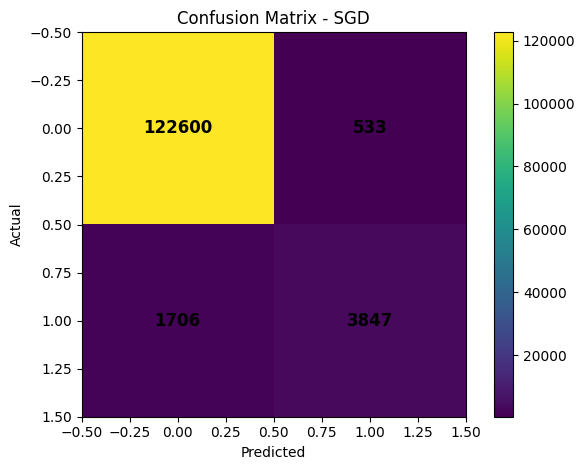

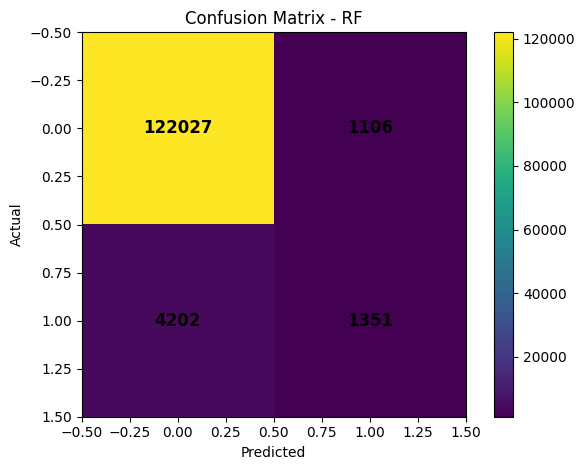

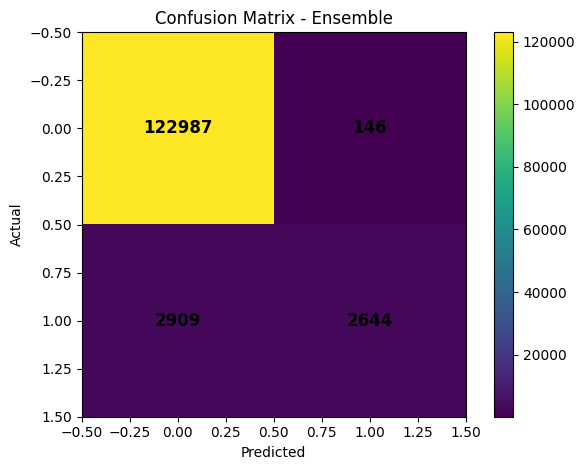

In [21]:
plot_and_save_confusion(true_arr, pred_sgd_arr, "Confusion Matrix - SGD", os.path.join(OUTPUT_DIR, "confusion_sgd.png"))
plot_and_save_confusion(true_arr, pred_rf_arr, "Confusion Matrix - RF", os.path.join(OUTPUT_DIR, "confusion_rf.png"))
plot_and_save_confusion(true_arr, pred_ens_arr, "Confusion Matrix - Ensemble", os.path.join(OUTPUT_DIR, "confusion_ensemble.png"))

# **Plot Precision-Recall Curve Comparison**

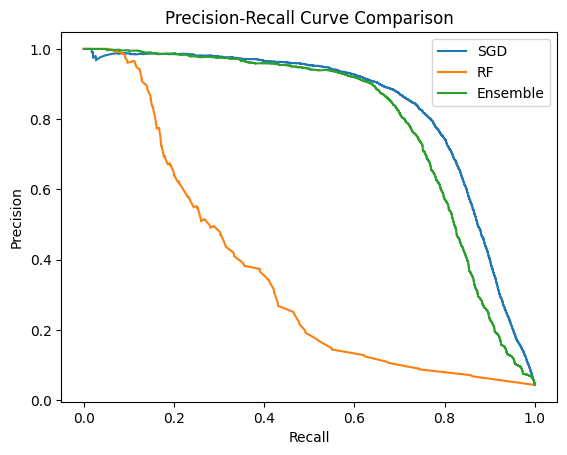

In [22]:
precision_sgd, recall_sgd, _ = precision_recall_curve(true_arr, probs_sgd_arr)
precision_rf, recall_rf, _ = precision_recall_curve(true_arr, probs_rf_arr)
precision_ens, recall_ens, _ = precision_recall_curve(true_arr, probs_ens_arr)
plt.figure()
plt.plot(recall_sgd, precision_sgd, label="SGD")
plt.plot(recall_rf, precision_rf, label="RF")
plt.plot(recall_ens, precision_ens, label="Ensemble")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
pr_out = os.path.join(OUTPUT_DIR, "precision_recall_comparison.png")
plt.savefig(pr_out)
plt.show()
plt.close()
saved_files.append(pr_out)

# **Plot ROC Curve Comparison**

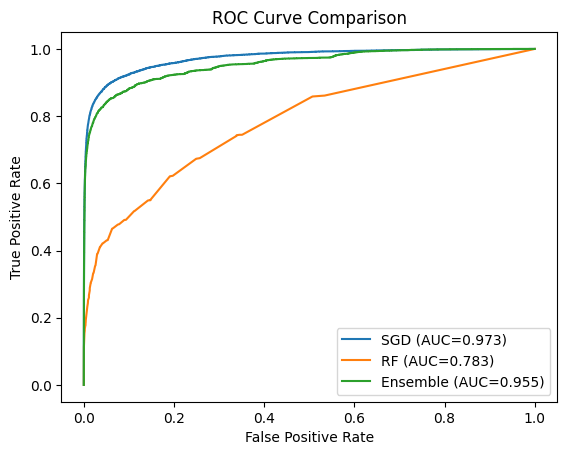

In [23]:
fpr_sgd, tpr_sgd, _ = roc_curve(true_arr, probs_sgd_arr)
fpr_rf, tpr_rf, _ = roc_curve(true_arr, probs_rf_arr)
fpr_ens, tpr_ens, _ = roc_curve(true_arr, probs_ens_arr)
auc_sgd = auc(fpr_sgd, tpr_sgd)
auc_rf = auc(fpr_rf, tpr_rf)
auc_ens = auc(fpr_ens, tpr_ens)
plt.figure()
plt.plot(fpr_sgd, tpr_sgd, label=f"SGD (AUC={auc_sgd:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.3f})")
plt.plot(fpr_ens, tpr_ens, label=f"Ensemble (AUC={auc_ens:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
roc_out = os.path.join(OUTPUT_DIR, "roc_comparison.png")
plt.savefig(roc_out)
plt.show()
plt.close()
saved_files.append(roc_out)
thresholds = np.linspace(0.0, 1.0, 101)

# **Metric Performance vs. Confidence Threshold**

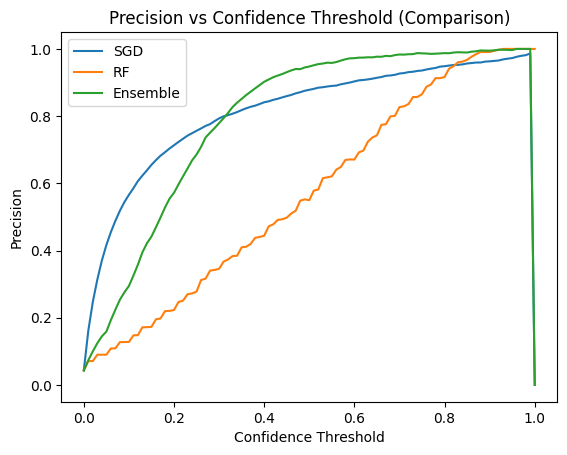

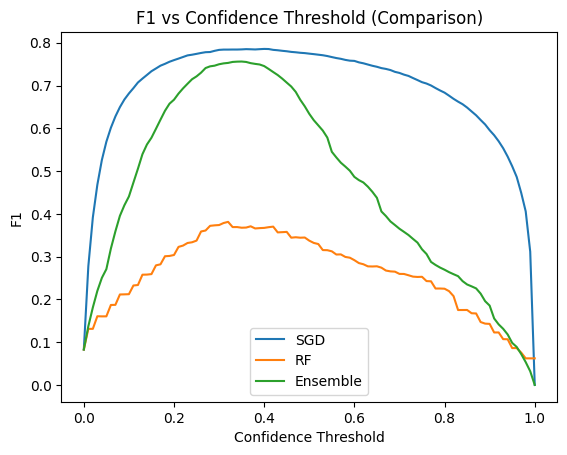

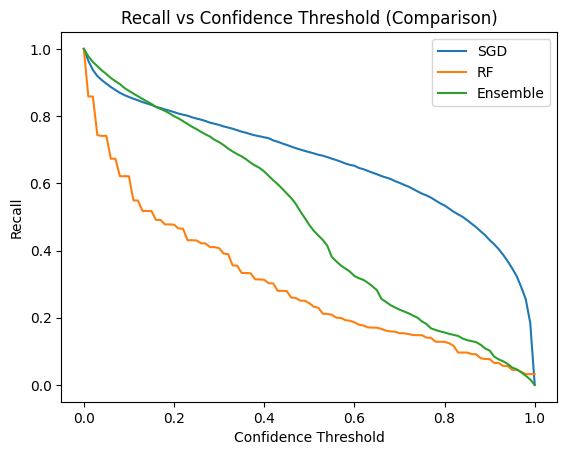

In [24]:
def compute_metric_vs_threshold(true_arr, probs, metric):
    values = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        try:
            if metric == "precision":
                val = precision_score(true_arr, preds, zero_division=0)
            elif metric == "recall":
                val = recall_score(true_arr, preds, zero_division=0)
            elif metric == "f1":
                val = f1_score(true_arr, preds, zero_division=0)
            else:
                val = 0.0
        except Exception:
            val = 0.0
        values.append(val)
    return np.array(values)
metrics = ["precision", "f1", "recall"]
for metric in metrics:
    sgd_vals = compute_metric_vs_threshold(true_arr, probs_sgd_arr, metric)
    rf_vals = compute_metric_vs_threshold(true_arr, probs_rf_arr, metric)
    ens_vals = compute_metric_vs_threshold(true_arr, probs_ens_arr, metric)
    plt.figure()
    plt.plot(thresholds, sgd_vals, label="SGD")
    plt.plot(thresholds, rf_vals, label="RF")
    plt.plot(thresholds, ens_vals, label="Ensemble")
    plt.xlabel("Confidence Threshold")
    plt.ylabel(metric.capitalize())
    plt.title(f"{metric.capitalize()} vs Confidence Threshold (Comparison)")
    plt.legend()
    outp = os.path.join(OUTPUT_DIR, f"{metric}_vs_confidence_comparison.png")
    plt.savefig(outp)
    plt.show()
    plt.close()
    saved_files.append(outp)

## **12. Saving Models and Artifacts**

# **Save Trained Models**

In [25]:
model_sgd_path = os.path.join(OUTPUT_DIR, "sgd_model.joblib")
model_rf_path = os.path.join(OUTPUT_DIR, "rf_model.joblib")
joblib.dump(sgd, model_sgd_path, compress=3)
joblib.dump(rf, model_rf_path, compress=3)
saved_files += [model_sgd_path, model_rf_path]

# **Save Preprocessing Config**

In [26]:
preproc_info_path = os.path.join(OUTPUT_DIR, "hashing_config.joblib")
joblib.dump({'n_features': N_FEATURES, 'hv_params': hv.get_params()}, preproc_info_path, compress=3)
saved_files.append(preproc_info_path)

# **Save Prediction Metrics CSV**

In [27]:
metrics_df = pd.DataFrame({
    "true": true_arr,
    "pred_sgd": pred_sgd_arr,
    "pred_rf": pred_rf_arr,
    "pred_ens": pred_ens_arr,
    "prob_sgd": probs_sgd_arr,
    "prob_rf": probs_rf_arr,
    "prob_ens": probs_ens_arr
})
metrics_csv = os.path.join(OUTPUT_DIR, "streaming_predictions_and_probs.csv")
metrics_df.to_csv(metrics_csv, index=False)
saved_files.append(metrics_csv)

# **Zip All Artifacts**

In [28]:
zip_path = os.path.join(OUTPUT_DIR, "sgd_rf_artifacts.zip")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fpath in saved_files:
        if os.path.exists(fpath):
            zf.write(fpath, arcname=os.path.basename(fpath))

# **Final Summary**

In [29]:
print("Saved artifacts:")
for f in saved_files:
    print(" -", f)
print("Zipped artifacts to:", zip_path)
print("\nSUMMARY:")
print("Number of drift points detected:", len(drifts), " at indices: ", drifts)
print("Final accuracies:")
print("  SGD acc:", accuracy_score(true_arr, pred_sgd_arr))
print("  RF acc:", accuracy_score(true_arr, pred_rf_arr))
print("  Ensemble acc:", accuracy_score(true_arr, pred_ens_arr))
print("All outputs and models are in:", OUTPUT_DIR)

Saved artifacts:
 - /kaggle/working/sgd_rf_results/classification_report_sgd.txt
 - /kaggle/working/sgd_rf_results/classification_report_rf.txt
 - /kaggle/working/sgd_rf_results/classification_report_ensemble.txt
 - /kaggle/working/sgd_rf_results/confusion_sgd.png
 - /kaggle/working/sgd_rf_results/confusion_rf.png
 - /kaggle/working/sgd_rf_results/confusion_ensemble.png
 - /kaggle/working/sgd_rf_results/precision_recall_comparison.png
 - /kaggle/working/sgd_rf_results/roc_comparison.png
 - /kaggle/working/sgd_rf_results/precision_vs_confidence_comparison.png
 - /kaggle/working/sgd_rf_results/f1_vs_confidence_comparison.png
 - /kaggle/working/sgd_rf_results/recall_vs_confidence_comparison.png
 - /kaggle/working/sgd_rf_results/sgd_model.joblib
 - /kaggle/working/sgd_rf_results/rf_model.joblib
 - /kaggle/working/sgd_rf_results/hashing_config.joblib
 - /kaggle/working/sgd_rf_results/streaming_predictions_and_probs.csv
Zipped artifacts to: /kaggle/working/sgd_rf_results/sgd_rf_artifacts.zip